# Group Meeting Figures

Five diagnostic and analytical plots for the group meeting.

**Plots:**
1. Calibration curve — predicted win probability vs observed frequency
2. Predicted vs actual score scatter — with residuals coloured by home/away
3. Player ranking caterpillar — top try-scorers with 95% credible intervals
4. Offensive vs defensive team strength scatter — current season
5. Scotland's paths to victory — Six Nations 2026 position probabilities

In [2]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns

from rugby_ranking.notebook_utils import setup_notebook_environment
from rugby_ranking.model.predictions import MatchPredictor
from rugby_ranking.model.season_predictor import SeasonPredictor
from rugby_ranking.model.league_table import BonusPointRules
from rugby_ranking.model.data_utils import prepare_season_data
from rugby_ranking.model.paths_to_victory import PathsAnalyzer
from rugby_ranking.utils.cli_helpers import load_checkpoint

# Scotland colours
SCOTLAND_BLUE  = '#003F87'
SCOTLAND_WHITE = '#FFFFFF'
ACCENT         = '#E8B43E'   # Gold
NEUTRAL        = '#888888'

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

dataset, df, model_dir = setup_notebook_environment()

Loading from: /home/daniel/repositories/personal/Rugby-Data
Loaded 14637 matches from /home/daniel/repositories/personal/Rugby-Data/json
Found 12465 unique players
Found 228 unique teams
✓ Loaded 434,884 player-match observations
  Players: 12,458
  Teams: 141
  Matches: 19,178
  Date range: 2006-09-02 to 2026-03-05

Data Quality Checks:
✓ Removed 1377 conversions and 451 penalties
  from 1034 player-match records in non-kicking positions
  Affected players: 446


In [3]:
# joint_model_v3 has 13k+ players and 1100+ team-seasons across all competitions
CHECKPOINT = 'joint_model_v3'
model, trace = load_checkpoint(CHECKPOINT, verbose=True)

print(f"\nModel config:")
print(f"  Separate kicking effect : {model.config.separate_kicking_effect}")
print(f"  Include defense         : {model.config.include_defense}")
print(f"  Time-varying effects    : {model.config.time_varying_effects}")

ℹ  Loading checkpoint: joint_model_v3
Loaded checkpoint from /home/daniel/.cache/rugby_ranking/joint_model_v3
✓ Loaded successfully
ℹ    Players: 13,786
ℹ    Team-seasons: 1126

Model config:
  Separate kicking effect : True
  Include defense         : True
  Time-varying effects    : False


## Calibration data

Temporal split: hold out the most recent 20% of played matches, sample 250 at random
for speed, then call `predict_teams_only` on each.  Takes a minute or two.

In [4]:
# Sort all played matches by date
all_played = sorted(
    [m for m in dataset.matches
     if m.is_played
     and getattr(m, 'home_score', None) is not None
     and getattr(m, 'away_score', None) is not None],
    key=lambda m: m.date,
)

n_test      = int(len(all_played) * 0.20)
test_matches = all_played[-n_test:]

rng     = np.random.default_rng(42)
sample  = rng.choice(len(test_matches), size=min(250, len(test_matches)), replace=False)
sample_matches = [test_matches[i] for i in sample]

print(f"Test set  : {len(test_matches)} matches  "
      f"({test_matches[0].date.date()} – {test_matches[-1].date.date()})")
print(f"Predicting: {len(sample_matches)} sampled matches …")

predictor = MatchPredictor(model, trace)

rows = []
for i, match in enumerate(sample_matches):
    try:
        pred = predictor.predict_teams_only(
            match.home_team, match.away_team, match.season, n_samples=500
        )
        rows.append({
            'pred_home_win'    : pred.home_win_prob,
            'pred_away_win'    : pred.away_win_prob,
            'actual_home_win'  : int(match.home_score > match.away_score),
            'pred_home_score'  : pred.home.mean,
            'pred_away_score'  : pred.away.mean,
            'pred_home_lo'     : pred.home.ci_lower,
            'pred_home_hi'     : pred.home.ci_upper,
            'pred_away_lo'     : pred.away.ci_lower,
            'pred_away_hi'     : pred.away.ci_upper,
            'actual_home_score': match.home_score,
            'actual_away_score': match.away_score,
        })
    except Exception:
        pass  # skip unknown teams
    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{len(sample_matches)} done")

calib = pd.DataFrame(rows)
correct = ((calib['pred_home_win'] > 0.5) == calib['actual_home_win'].astype(bool)).mean()
print(f"\nGenerated {len(calib)} predictions")
print(f"Winner prediction accuracy (home-win threshold): {correct:.1%}")

Test set  : 2878 matches  (2023-04-15 – 2026-03-05)
Predicting: 250 sampled matches …
  50/250 done
  100/250 done
  150/250 done
  200/250 done
  250/250 done

Generated 214 predictions
Winner prediction accuracy (home-win threshold): 67.3%


## Figure 1 – Calibration curve

Probability calibration: when the model says 70%, does home team win 70% of the time?
This is the analogue of a p–p plot that astronomers will recognise.

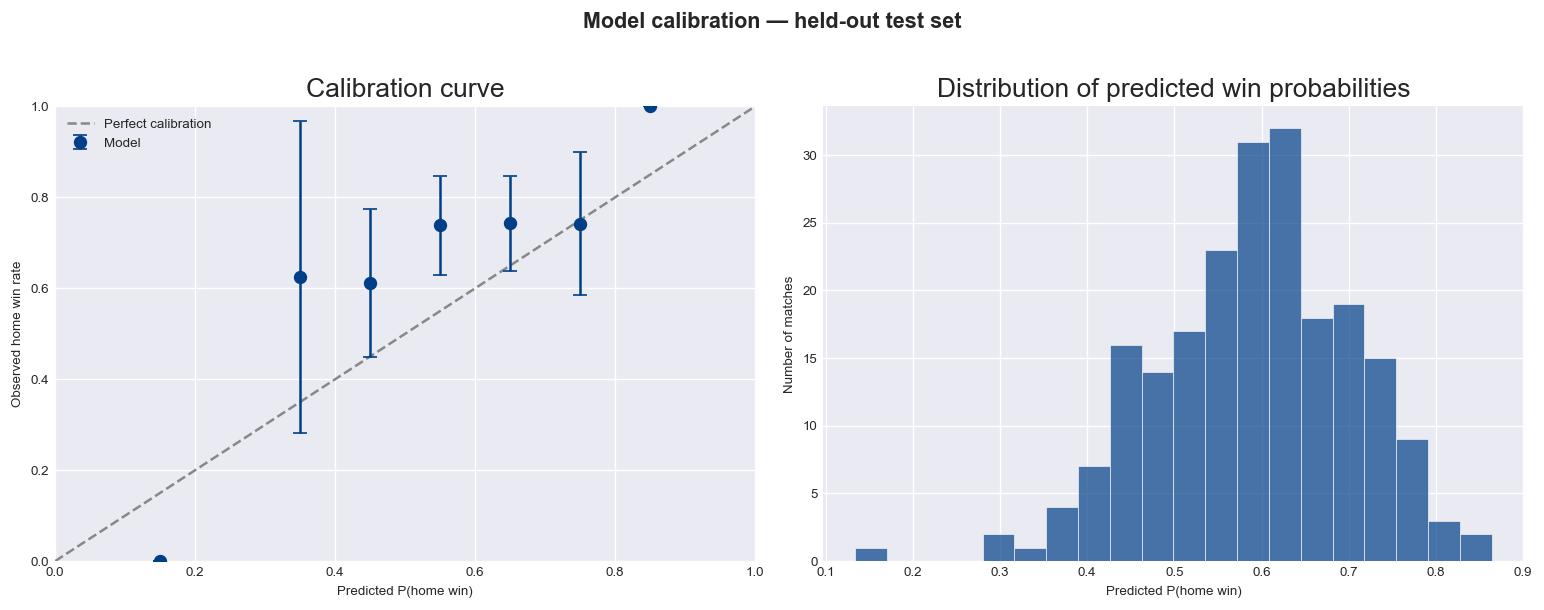

Saved fig1_calibration.pdf


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── left panel: calibration curve ──────────────────────────────────────────
ax = axes[0]
bins = np.linspace(0, 1, 11)          # decile buckets
bin_mid  = (bins[:-1] + bins[1:]) / 2

obs_rate, se = [], []
for lo, hi in zip(bins[:-1], bins[1:]):
    mask = (calib['pred_home_win'] >= lo) & (calib['pred_home_win'] < hi)
    n    = mask.sum()
    p    = calib.loc[mask, 'actual_home_win'].mean() if n > 0 else np.nan
    obs_rate.append(p)
    se.append(np.sqrt(p * (1 - p) / n) if (n > 0 and not np.isnan(p)) else 0)

obs_rate = np.array(obs_rate)
se       = np.array(se)

ax.plot([0, 1], [0, 1], '--', color=NEUTRAL, lw=1.5, label='Perfect calibration')
ax.errorbar(
    bin_mid, obs_rate, yerr=2 * se,
    fmt='o', color=SCOTLAND_BLUE, ms=7, capsize=4, lw=1.5, label='Model'
)
ax.set_xlabel('Predicted P(home win)')
ax.set_ylabel('Observed home win rate')
ax.set_title('Calibration curve')
ax.legend(frameon=False)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# ── right panel: reliability histogram ─────────────────────────────────────
ax = axes[1]
ax.hist(calib['pred_home_win'], bins=20, color=SCOTLAND_BLUE, alpha=0.7, edgecolor='white')
ax.set_xlabel('Predicted P(home win)')
ax.set_ylabel('Number of matches')
ax.set_title('Distribution of predicted win probabilities')

plt.suptitle('Model calibration — held-out test set', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig1_calibration.pdf', bbox_inches='tight')
plt.show()
print("Saved fig1_calibration.pdf")

## Figure 2 – Predicted vs actual score scatter

Two points per match (home team, away team).  Residuals coloured by home/away.
The 90% CI coverage rate tells us whether the credible intervals are well-sized.

RMSE           : 13.8 pts
90% CI coverage: 85.0%  (nominal 90%)


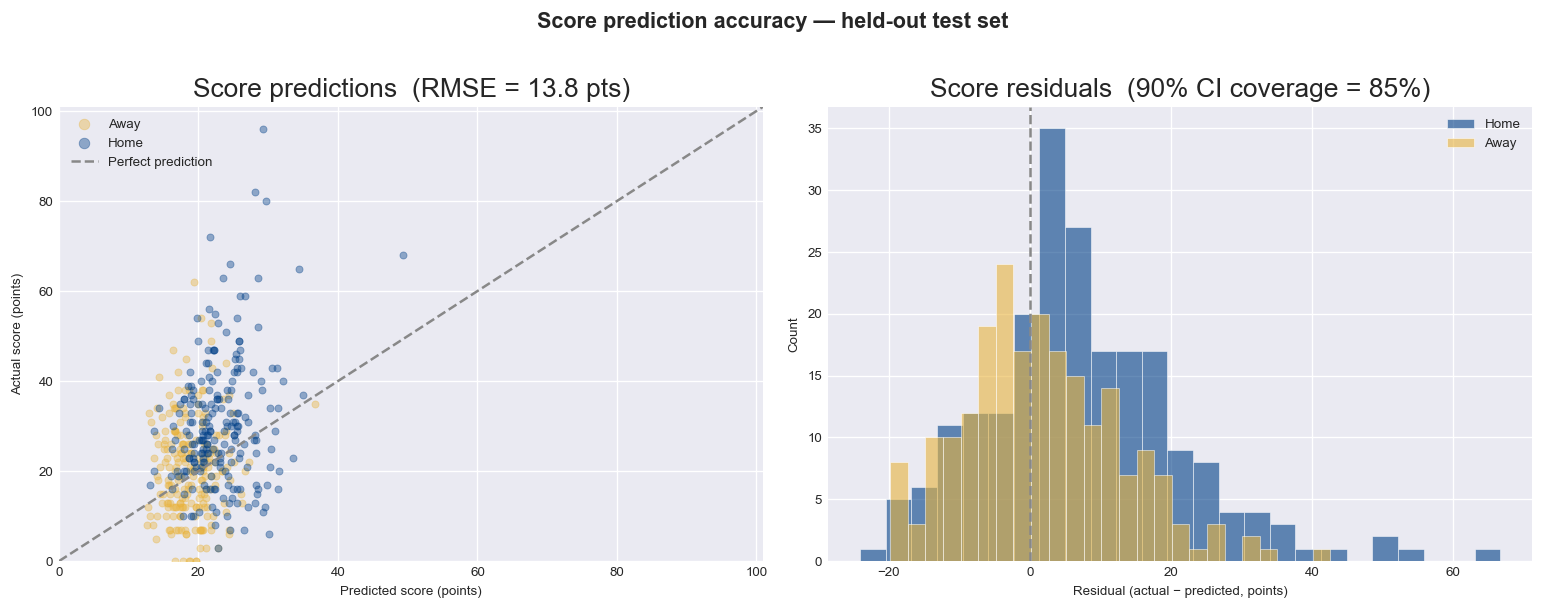

Saved fig2_score_scatter.pdf


In [6]:
# Combine home and away into one long-form frame
home_df = calib[['pred_home_score', 'actual_home_score',
                  'pred_home_lo', 'pred_home_hi']].copy()
home_df.columns = ['pred', 'actual', 'lo', 'hi']
home_df['side'] = 'Home'

away_df = calib[['pred_away_score', 'actual_away_score',
                  'pred_away_lo', 'pred_away_hi']].copy()
away_df.columns = ['pred', 'actual', 'lo', 'hi']
away_df['side'] = 'Away'

scores = pd.concat([home_df, away_df], ignore_index=True)
scores['residual'] = scores['actual'] - scores['pred']
scores['in_ci']    = (scores['actual'] >= scores['lo']) & (scores['actual'] <= scores['hi'])

rmse    = np.sqrt((scores['residual'] ** 2).mean())
ci_cov  = scores['in_ci'].mean()
print(f"RMSE           : {rmse:.1f} pts")
print(f"90% CI coverage: {ci_cov:.1%}  (nominal 90%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── left panel: scatter ─────────────────────────────────────────────────────
ax = axes[0]
colours = {"Home": SCOTLAND_BLUE, "Away": ACCENT}
for side, grp in scores.groupby('side'):
    ax.scatter(
        grp['pred'], grp['actual'],
        c=colours[side], alpha=0.4, s=18, label=side, rasterized=True
    )

lim = (0, scores[['pred', 'actual']].max().max() + 5)
ax.plot(lim, lim, '--', color=NEUTRAL, lw=1.5, label='Perfect prediction')
ax.set_xlim(*lim); ax.set_ylim(*lim)
ax.set_xlabel('Predicted score (points)')
ax.set_ylabel('Actual score (points)')
ax.set_title(f'Score predictions  (RMSE = {rmse:.1f} pts)')
ax.legend(frameon=False, markerscale=1.5)

# ── right panel: residuals ─────────────────────────────────────────────────
ax = axes[1]
ax.hist(scores.loc[scores.side == 'Home', 'residual'], bins=25,
        color=SCOTLAND_BLUE, alpha=0.6, label='Home', edgecolor='white')
ax.hist(scores.loc[scores.side == 'Away', 'residual'], bins=25,
        color=ACCENT, alpha=0.6, label='Away', edgecolor='white')
ax.axvline(0, color=NEUTRAL, lw=1.5, ls='--')
ax.set_xlabel('Residual (actual − predicted, points)')
ax.set_ylabel('Count')
ax.set_title(f'Score residuals  (90% CI coverage = {ci_cov:.0%})')
ax.legend(frameon=False)

plt.suptitle('Score prediction accuracy — held-out test set', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig2_score_scatter.pdf', bbox_inches='tight')
plt.show()
print("Saved fig2_score_scatter.pdf")

## Figure 3 – Player ranking caterpillar

Posterior mean ± 95% credible interval for the top try-scoring ability effects.
Scottish club players (Glasgow Warriors / Edinburgh Rugby) highlighted in gold.
Width of interval reflects data quantity — new/rare players shrink toward zero.

Scottish-club players in top 30: 4
                  player  effect_mean  total_scores
9            Dylan Evans     1.131827            12
11          George Horne     1.126477            78
18  Patrick Schickerling     1.042046            14
20       Johnny Matthews     1.036755            60


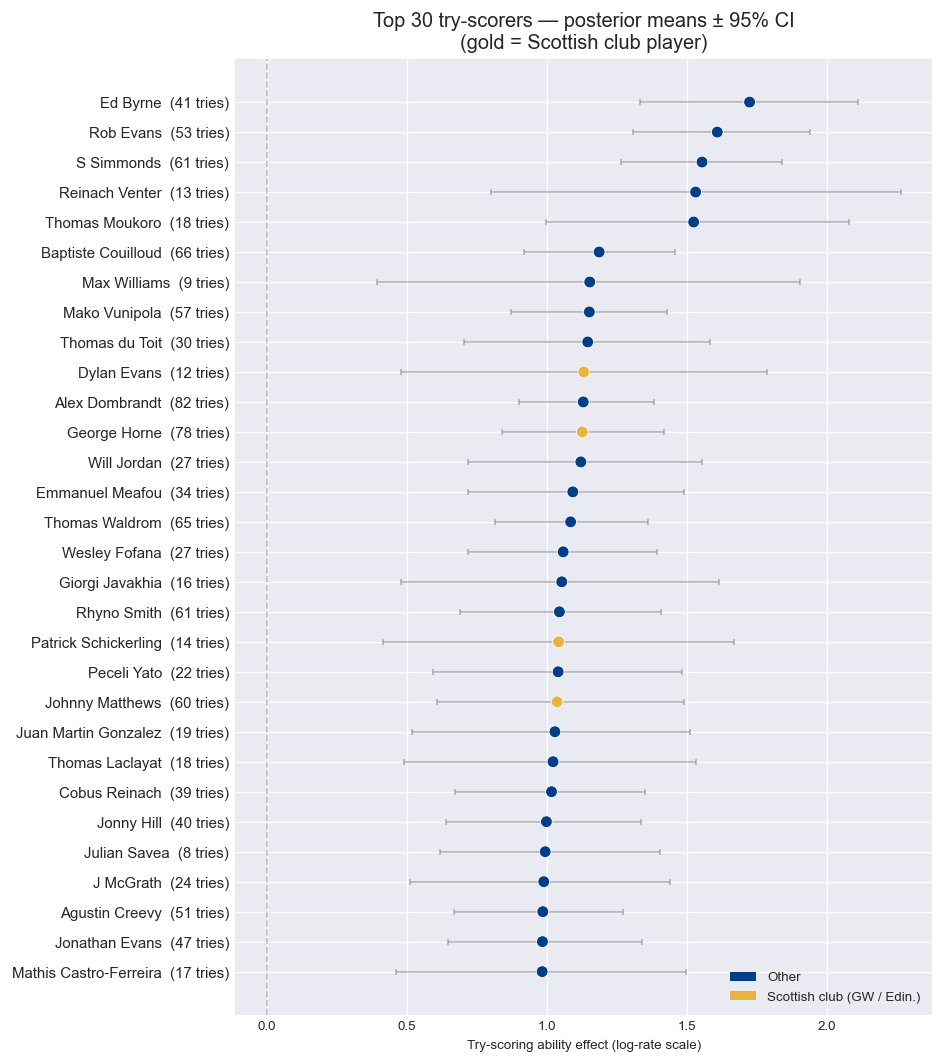

Saved fig3_player_caterpillar.pdf


In [7]:
# Get rankings — top 30 try-scorers with at least 5 career tries
rankings = model.get_player_rankings(
    trace, score_type='tries', top_n=30, df=df, min_scores=5
)

# Identify Scottish club players from the match dataframe
scottish_clubs = {'Glasgow Warriors', 'Edinburgh Rugby'}
scot_players = set(
    df.loc[df['team'].isin(scottish_clubs), 'player_name'].unique()
)

rankings['is_scottish'] = rankings['player'].isin(scot_players)
print(f"Scottish-club players in top 30: "
      f"{rankings['is_scottish'].sum()}")
print(rankings[rankings['is_scottish']][['player', 'effect_mean', 'total_scores']])

# ── plot ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 9))

y = np.arange(len(rankings))
colours = [ACCENT if s else SCOTLAND_BLUE for s in rankings['is_scottish']]

ax.errorbar(
    rankings['effect_mean'], y,
    xerr=[
        rankings['effect_mean'] - rankings['effect_lower'],
        rankings['effect_upper'] - rankings['effect_mean'],
    ],
    fmt='none', color=NEUTRAL, lw=1, capsize=2, alpha=0.6, zorder=1
)
ax.scatter(
    rankings['effect_mean'], y,
    c=colours, s=50, zorder=2, edgecolors='white', linewidths=0.5
)
ax.axvline(0, color=NEUTRAL, lw=1, ls='--', alpha=0.5)

# Player labels — total tries in parentheses
ax.set_yticks(y)
labels = [
    f"{row.player}  ({int(row.total_scores)} tries)"
    for _, row in rankings.iterrows()
]
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()

ax.set_xlabel('Try-scoring ability effect (log-rate scale)')
ax.set_title(
    'Top 30 try-scorers — posterior means ± 95% CI\n'
    '(gold = Scottish club player)',
    fontsize=12
)

legend_elements = [
    mpatches.Patch(facecolor=SCOTLAND_BLUE, label='Other'),
    mpatches.Patch(facecolor=ACCENT, label='Scottish club (GW / Edin.)'),
]
ax.legend(handles=legend_elements, frameon=False, loc='lower right')

plt.tight_layout()
plt.savefig('fig3_player_caterpillar.pdf', bbox_inches='tight')
plt.show()
print("Saved fig3_player_caterpillar.pdf")

## Figure 4 – Offensive vs defensive team strength

Each team-season is a point. Offensive strength (γ) comes from `get_team_rankings`,
defensive strength (δ) from `get_defensive_rankings`.  Scottish teams highlighted.

> **Note:** defensive rankings require `model.config.include_defense = True`.
> If the loaded checkpoint lacks this, the cell gracefully falls back to offensive-only.

Attack rankings for 2025-2026: 20 teams
Defensive rankings for 2025-2026: 20 teams


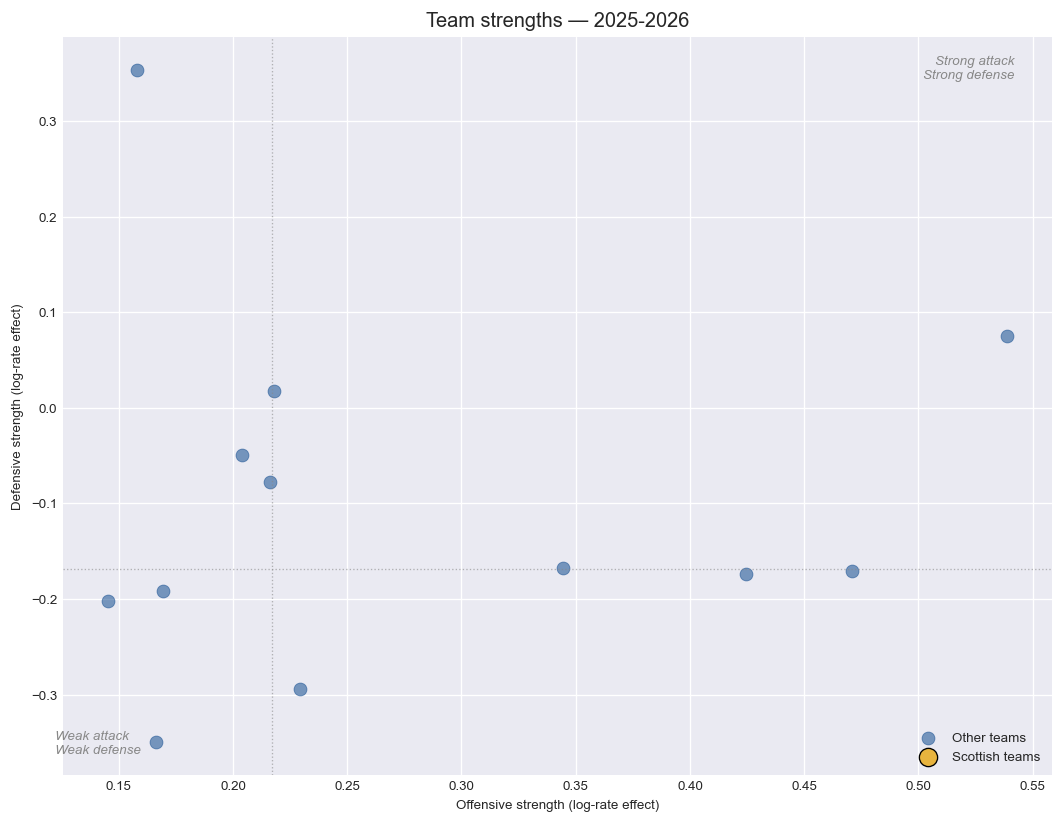

Saved fig4_team_strength.pdf


In [8]:
SEASON = '2025-2026'

attack = model.get_team_rankings(trace, season=SEASON, score_type='tries')
print(f"Attack rankings for {SEASON}: {len(attack)} teams")

try:
    defense = model.get_defensive_rankings(trace, season=SEASON, score_type='tries')
    has_defense = True
    print(f"Defensive rankings for {SEASON}: {len(defense)} teams")
except ValueError as e:
    has_defense = False
    print(f"No defensive rankings available ({e})")
    print("Try loading 'model_2023_2024_with_defense' instead.")

if has_defense:
    combined = attack[['team', 'effect_mean', 'effect_std']].rename(
        columns={'effect_mean': 'attack', 'effect_std': 'attack_std'}
    ).merge(
        defense[['team', 'defense_mean', 'defense_std']],
        on='team', how='inner'
    )
else:
    # Fallback: show attack ranking only as a bar chart
    combined = None

# ── plot ────────────────────────────────────────────────────────────────────
scot_teams = {'Glasgow Warriors', 'Edinburgh Rugby', 'Scotland'}

if has_defense and combined is not None:
    fig, ax = plt.subplots(figsize=(9, 7))

    is_scot = combined['team'].isin(scot_teams)
    ax.scatter(
        combined.loc[~is_scot, 'attack'],
        combined.loc[~is_scot, 'defense_mean'],
        c=SCOTLAND_BLUE, alpha=0.5, s=60, label='Other teams'
    )
    ax.scatter(
        combined.loc[is_scot, 'attack'],
        combined.loc[is_scot, 'defense_mean'],
        c=ACCENT, s=120, zorder=3, edgecolors='black', lw=0.8,
        label='Scottish teams'
    )

    # Label Scottish teams
    for _, row in combined[is_scot].iterrows():
        ax.annotate(
            row['team'], (row['attack'], row['defense_mean']),
            textcoords='offset points', xytext=(6, 4), fontsize=9,
            color=ACCENT, fontweight='bold'
        )

    # Quadrant lines at medians
    ax.axvline(combined['attack'].median(),    color=NEUTRAL, lw=0.8, ls=':', alpha=0.6)
    ax.axhline(combined['defense_mean'].median(), color=NEUTRAL, lw=0.8, ls=':', alpha=0.6)

    # Quadrant labels
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    ax.text(xlim[1]*0.97, ylim[1]*0.95, 'Strong attack\nStrong defense',
            ha='right', va='top', fontsize=8, color=NEUTRAL, style='italic')
    ax.text(xlim[0]*0.97, ylim[0]*0.95, 'Weak attack\nWeak defense',
            ha='left', va='bottom', fontsize=8, color=NEUTRAL, style='italic')

    ax.set_xlabel('Offensive strength (log-rate effect)')
    ax.set_ylabel('Defensive strength (log-rate effect)')
    ax.set_title(f'Team strengths — {SEASON}', fontsize=12)
    ax.legend(frameon=False)

else:
    # Fallback: offensive ranking only
    fig, ax = plt.subplots(figsize=(9, 5))
    is_scot = attack['team'].isin(scot_teams)
    colours = [ACCENT if s else SCOTLAND_BLUE for s in is_scot]

    ax.barh(attack['team'][::-1], attack['effect_mean'][::-1], color=colours[::-1], alpha=0.8)
    ax.axvline(0, color=NEUTRAL, lw=1, ls='--')
    ax.set_xlabel('Offensive strength (log-rate effect)')
    ax.set_title(f'Team offensive rankings — {SEASON}', fontsize=12)

plt.tight_layout()
plt.savefig('fig4_team_strength.pdf', bbox_inches='tight')
plt.show()
print("Saved fig4_team_strength.pdf")

## Figure 5 – Scotland's paths to victory

Run 1000 Monte Carlo simulations of the remaining Six Nations 2026 fixtures.
Plot the full position probability distribution for all 6 nations, with Scotland
highlighted, plus a bar chart of the critical conditions Scotland needs.

> **Competition name:** print the cell below first to verify the exact string used
> in your dataset, then adjust `SIX_NATIONS_COMP` accordingly.

In [9]:
SEASON = '2026-2027'
# Print top competitions to find the right string for Six Nations
from collections import Counter
comp_counts = Counter(m.competition for m in dataset.matches)
print("Top 30 competitions in dataset:")
for comp, n in comp_counts.most_common(30):
    print(f"  {n:6d}  {comp!r}")

Top 30 competitions in dataset:
    2962  'celtic'
    2599  'premiership'
    2106  'super-rugby'
    2066  'top14'
    1330  'euro-champions'
    1222  'euro-challenge'
     760  'pro-d2'
     521  'championship'
     361  'rugby-world'
     221  'mid-year-internationals'
     177  'end-of-year-internationals'
     140  'npc'
     105  'six-nations'
      67  'currie-cup'


In [10]:
# ── Adjust these two strings based on the output above ─────────────────────
SIX_NATIONS_COMP   = 'six'            # substring match — 'six' will match 'Six Nations'
SIX_NATIONS_SEASON = '2025-2026'
SCOTLAND_TEAM_NAME = 'Scotland'        # as it appears in the dataset
# ───────────────────────────────────────────────────────────────────────────

played_matches, remaining_fixtures = prepare_season_data(
    dataset,
    season=SIX_NATIONS_SEASON,
    competition=SIX_NATIONS_COMP,
    include_tries=True,
)

print(f"Played    : {len(played_matches)  // 2} matches")
print(f"Remaining : {len(remaining_fixtures)} fixtures")
print(f"\nNext fixtures:")
print(remaining_fixtures.head(10).to_string(index=False))

Played    : 15 matches
Remaining : 0 fixtures

Next fixtures:
Empty DataFrame
Columns: []
Index: []


In [11]:
match_predictor = MatchPredictor(model, trace)

# Six Nations uses 6 teams, no playoffs, no bonus points
season_predictor = SeasonPredictor(
    match_predictor=match_predictor,
    competition=BonusPointRules.URC,   # closest generic rules; or pass 'six_nations' if available
    playoff_spots=0,
)

print("Running 1000 Monte Carlo season simulations …")
season_pred = season_predictor.predict_season(
    played_matches=played_matches,
    remaining_fixtures=remaining_fixtures,
    season=SIX_NATIONS_SEASON,
    n_simulations=1000,
    return_samples=True,
)
print("Done.")
print(season_predictor.format_predictions(season_pred))

Running 1000 Monte Carlo season simulations …
Done.
SEASON PREDICTION

CURRENT STANDINGS:
----------------------------------------------------------------------
 1. France               P: 5 W: 4 Pts: 21
 2. England              P: 5 W: 4 Pts: 20
 3. Ireland              P: 5 W: 4 Pts: 19
 4. Scotland             P: 5 W: 2 Pts: 11
 5. Italy                P: 5 W: 1 Pts:  5
 6. Wales                P: 5 W: 0 Pts:  3


PREDICTED FINAL STANDINGS:
----------------------------------------------------------------------
 1. France               Pts:21.0 Diff:+125.0
 2. England              Pts:20.0 Diff:+74.0
 3. Ireland              Pts:19.0 Diff:+18.0
 4. Scotland             Pts:11.0 Diff:-16.0
 5. Italy                Pts:5.0 Diff:-82.0
 6. Wales                Pts:3.0 Diff:-119.0


PLAYOFF PROBABILITIES (Top 0):
----------------------------------------------------------------------
France               0.0%
England              0.0%



In [12]:
analyzer = PathsAnalyzer(
    season_prediction=season_pred,
    match_predictor=match_predictor,
)

scotland_paths = analyzer.analyze_paths(
    team=SCOTLAND_TEAM_NAME,
    target_position=1,
    method='auto',
)

print(scotland_paths.narrative)

PATHS TO VICTORY: SCOTLAND

Scotland can finish 1st with 0.0% probability (±1.0%).

⊗ Scotland would need several unlikely results.

Analysis method: COMBINATORIAL
(Exact combinatorial enumeration of all possible outcomes)


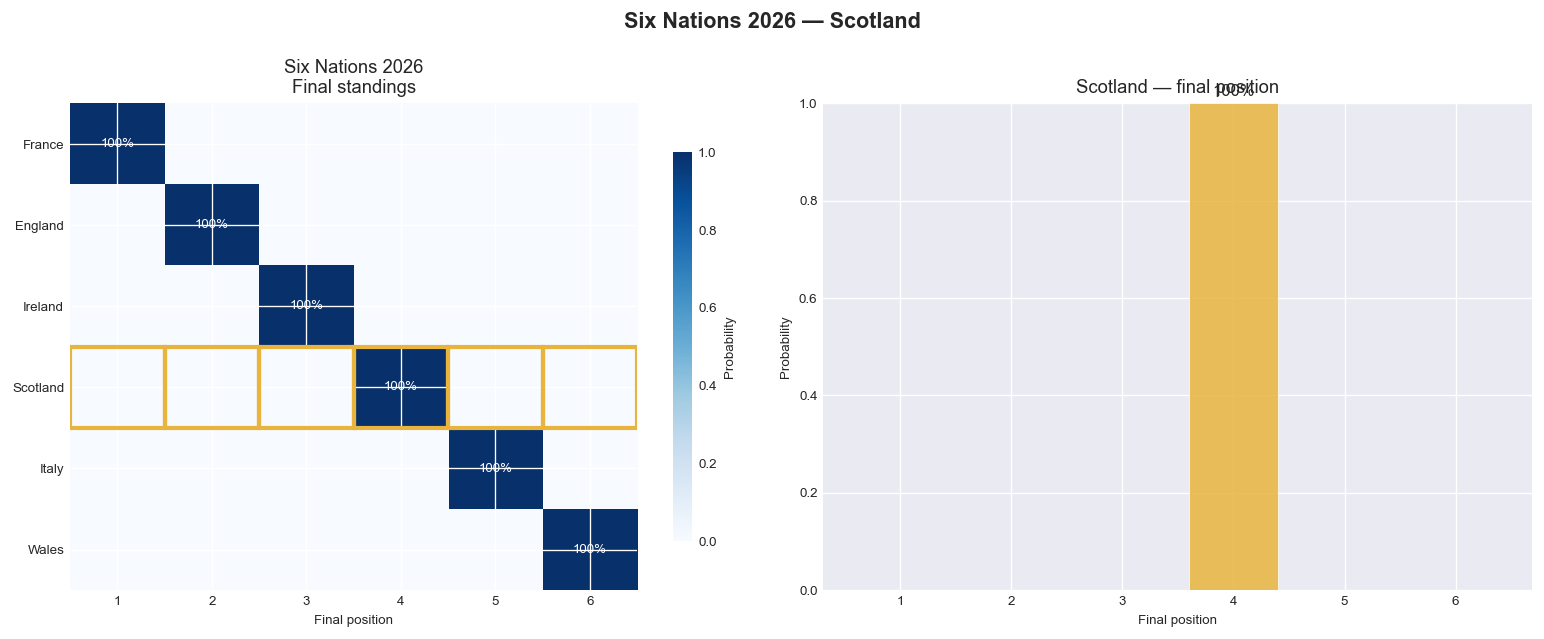

Saved fig5_scotland_paths.pdf


In [13]:
# position_probabilities has P(pos 1)…P(pos N) columns PLUS a 'most_likely_position'
# column — filter to only the probability columns before indexing.
pos_cols  = [c for c in season_pred.position_probabilities.columns
             if str(c).startswith('P(pos')]
pos_probs = season_pred.position_probabilities[pos_cols]
teams     = list(pos_probs.index)
n_pos     = len(pos_cols)          # now correct: one column per position

is_complete = len(remaining_fixtures) == 0
subtitle    = 'Final standings' if is_complete else 'Predicted final position probabilities'

n_teams = len(teams)
# Scale figure height to number of teams so heatmap cells aren't tiny or huge
fig, axes = plt.subplots(1, 2, figsize=(13, max(4, n_teams * 0.65 + 1.5)))

# ── left panel: position probability heatmap ───────────────────────────────
ax = axes[0]
im = ax.imshow(pos_probs.values, cmap='Blues', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(n_pos))
ax.set_xticklabels([str(i + 1) for i in range(n_pos)])
ax.set_yticks(range(n_teams))
ax.set_yticklabels(teams)
ax.set_xlabel('Final position')
ax.set_title(f'Six Nations 2026\n{subtitle}', fontsize=11)

# Highlight Scotland row with gold border
if SCOTLAND_TEAM_NAME in teams:
    scot_row = teams.index(SCOTLAND_TEAM_NAME)
    for col in range(n_pos):
        ax.add_patch(plt.Rectangle(
            (col - 0.5, scot_row - 0.5), 1, 1,
            fill=False, edgecolor=ACCENT, lw=2.5, zorder=3
        ))

# Annotate cells with probability text
for i in range(n_teams):
    for j in range(n_pos):
        p = pos_probs.iloc[i, j]
        if p > 0.04:
            ax.text(j, i, f'{p:.0%}', ha='center', va='center',
                    fontsize=8, color='white' if p > 0.5 else 'black')

plt.colorbar(im, ax=ax, label='Probability', shrink=0.8)

# ── right panel: Scotland position bar chart ────────────────────────────────
ax = axes[1]
if SCOTLAND_TEAM_NAME in teams:
    scot_pos_probs = pos_probs.loc[SCOTLAND_TEAM_NAME].values
    positions      = list(range(1, n_pos + 1))
    peak           = scot_pos_probs.max()
    bar_colours    = [ACCENT if p == peak else SCOTLAND_BLUE for p in scot_pos_probs]

    bars = ax.bar(positions, scot_pos_probs, color=bar_colours, alpha=0.85, edgecolor='white')
    ax.set_xlabel('Final position')
    ax.set_ylabel('Probability')
    ax.set_xticks(positions)
    ax.set_ylim(0, min(1.0, peak * 1.3))
    ax.set_title('Scotland — final position', fontsize=11)

    for bar, p in zip(bars, scot_pos_probs):
        if p > 0.01:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{p:.0%}', ha='center', va='bottom', fontsize=10
            )

    # Key conditions annotation (only relevant when fixtures remain)
    if scotland_paths.conditions:
        cond_text = "Key conditions:\n" + "\n".join(
            f"  {'✓' if c.team_controls else '○'} "
            f"{c.game[0].split()[-1]} v {c.game[1].split()[-1]}  "
            f"[{c.frequency:.0%}]"
            for c in scotland_paths.conditions[:5]
        )
        ax.text(
            0.97, 0.97, cond_text,
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8, family='monospace',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )

fig.suptitle('Six Nations 2026 — Scotland', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig('fig5_scotland_paths.pdf', bbox_inches='tight')
plt.show()
print("Saved fig5_scotland_paths.pdf")